RQ4: To what extent do evasion attacks generated with no information about the model parameters (black-box) compare to evasion attacks against models hardened using adversarial training with full parameter knowledge (white-box)?

H40: Adversarial training does not significantly improve the robustness of ML-based IDS models against evasion attacks in a black-box analysis setting.

H4a: Adversarial training significantly improves the robustness of ML-based IDS models against evasion attacks in a black-box analysis setting.

In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import pandas as pd
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
N_BOOT = 5000
N_EVAL = 30000
N_SEEDS = 5
ADV_TRAIN_PCT = 0.60
RNG = np.random.default_rng(42)

In [3]:
df = pd.read_csv('data/clean_sample_150000.csv')
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
X = df.drop(columns=['label', 'flowid'], errors='ignore').select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test_arr = y_test.reset_index(drop=True).to_numpy()

In [5]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [6]:
def load_adv(path):
    d = pd.read_csv(path)
    drop = [c for c in ['true_label', 'pred_clean', 'pred_adv', 'y_pred', 'confidence']
            if c in d.columns]
    Xa = d.drop(columns=drop, errors='ignore').select_dtypes(include=[np.number])
    Xa.replace([np.inf, -np.inf], np.nan, inplace=True)
    Xa.fillna(0, inplace=True)
    Xa = Xa.reindex(columns=X_train.columns, fill_value=0).astype('float32')
    ya = d['true_label'].values.astype(int)
    return Xa.values, ya

In [7]:
def strat_sample_seeded(Xe, ye, n=N_EVAL, seed=0):
    rng = np.random.default_rng(seed)
    n = min(n, 3 * min((ye == c).sum() for c in [0, 1, 2]))
    idx = np.concatenate([rng.choice(np.where(ye == c)[0], n // 3, replace=False) for c in [0, 1, 2]])
    return Xe[idx], ye[idx]

In [8]:
base_model = base_xgb()
base_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [9]:
yp_base_clean = base_model.predict(X_test)
yp_base_prob = base_model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test_arr, yp_base_clean))
print("Macro Percision:", precision_score(y_test_arr, yp_base_clean, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test_arr, yp_base_clean, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test_arr, yp_base_clean, average='weighted'))
print("Macro F1:", f1_score(y_test_arr, yp_base_clean, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test_arr, yp_base_prob, multi_class="ovr", average="weighted"))
print(classification_report(y_test_arr, yp_base_clean, target_names=le.classes_))

Accuracy: 0.9070666666666667
Macro Percision: 0.908725730115699
Macro Recall: 0.9070666666666667
Weighted F1: 0.9069017276411161
Macro F1: 0.9069017276411162
ROC-AUC: 0.9828945200000001
                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



In [10]:
adv_full_X, adv_full_y = load_adv('data/adversarial_full_epsilon_0.5.csv')
n_aug   = int(len(adv_full_y) * ADV_TRAIN_PCT)
aug_idx = RNG.choice(len(adv_full_y), size=n_aug, replace=True)
X_hard_train = np.vstack([X_train.values, adv_full_X[aug_idx]]).astype('float32')
y_hard_train = np.concatenate([y_train.reset_index(drop=True).to_numpy(), adv_full_y[aug_idx]])
print("Hardened training set:", len(y_hard_train))
print("Clean:", len(X_train))
print(f'Adversarial (ε=0.5) : {n_aug:,}  ({ADV_TRAIN_PCT*100:.0f}% of full adv file)')

Hardened training set: 255000
Clean: 120000
Adversarial (ε=0.5) : 135,000  (60% of full adv file)


In [11]:
hardened_model = base_xgb()
hardened_model.fit(X_hard_train, y_hard_train, verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [12]:
yp_hard_clean = hardened_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test_arr, yp_hard_clean))
print("Macro F1:", f1_score(y_test_arr, yp_hard_clean, average="macro"))
print(classification_report(y_test_arr, yp_hard_clean, target_names=le.classes_))

Accuracy: 0.9046666666666666
Macro F1: 0.9044950762915843
                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.86     10000

      accuracy                           0.90     30000
     macro avg       0.91      0.90      0.90     30000
  weighted avg       0.91      0.90      0.90     30000



In [13]:
def benign_fpr(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    benign = y_true == 0
    return float((y_pred[benign] != 0).mean()) if benign.any() else 0.0

In [14]:
def macro_pr(y_true, y_pred, K=3):          # macro precision, macro recall via confusion matrix
    cm = np.bincount(y_true*K + y_pred, minlength=K*K).reshape(K, K).astype(float)
    d = np.diag(cm); col = cm.sum(0); row = cm.sum(1)
    prec = np.where(col > 0, d/col, 0).mean()
    rec  = np.where(row > 0, d/row, 0).mean()
    return float(prec), float(rec)

In [15]:
EVAL_FILES = {'Control (clean)': None,
              'Epsilon = 0.01': 'data/adversarial_full_epsilon_0.01.csv',
              'Epsilon = 0.05': 'data/adversarial_full_epsilon_0.05.csv',
              'Epsilon = 0.10': 'data/adversarial_full_epsilon_0.1.csv',
              'Epsilon = 0.50': '__holdout__'}  
adv5_X, adv5_y = load_adv('data/adversarial_full_epsilon_0.5.csv')
ytr_np = y_train.reset_index(drop=True).to_numpy()

In [16]:
fixed_eval, base_f1 = {}, {}
for name, path in EVAL_FILES.items():
    if path is None: fixed_eval[name] = (X_test.values, y_test_arr)
    elif path == '__holdout__': fixed_eval[name] = None
    else: fixed_eval[name] = strat_sample_seeded(*load_adv(path), seed=42)
    if fixed_eval[name] is not None: Xe, ye = fixed_eval[name]; base_f1[name] = f1_score(ye, base_model.predict(Xe), average='macro')
per_seed = {name: [] for name in EVAL_FILES}
for s in range(N_SEEDS):
    rng  = np.random.default_rng(1000 + s)
    perm = rng.permutation(len(adv5_y)); cut = int(ADV_TRAIN_PCT * len(perm))
    tr_i, ho_i = perm[:cut], perm[cut:]
    X_hard = np.vstack([X_train.values, adv5_X[tr_i]]).astype('float32')
    y_hard = np.concatenate([ytr_np, adv5_y[tr_i]])
    hardened = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric='mlogloss', tree_method='hist', random_state=s)
    hardened.fit(X_hard, y_hard, verbose=False)
    for name, path in EVAL_FILES.items():
        if path == '__holdout__':
            Xe, ye = strat_sample_seeded(adv5_X[ho_i], adv5_y[ho_i], seed=s)
            d = (f1_score(ye, hardened.predict(Xe), average='macro') - f1_score(ye, base_model.predict(Xe), average='macro'))
        else:
            Xe, ye = fixed_eval[name]
            d = f1_score(ye, hardened.predict(Xe), average='macro') - base_f1[name]
        per_seed[name].append(d)
print(f"{'Condition':<18}{'mean ΔF1':>9}{'sd':>8}{'min':>9}{'max':>9}  sign-stable")
for name in EVAL_FILES:
    a = np.array(per_seed[name])
    stable = 'yes' if ((a > 0).all() or (a < 0).all()) else 'NO  <- not robust'
    print(f"{name:<18}{a.mean():+9.4f}{a.std():8.4f}{a.min():+9.4f}{a.max():+9.4f}  {stable}")

Condition          mean ΔF1      sd      min      max  sign-stable
Control (clean)     -0.0029  0.0003  -0.0033  -0.0024  yes
Epsilon = 0.01      +0.0628  0.0023  +0.0585  +0.0647  yes
Epsilon = 0.05      +0.3045  0.0012  +0.3026  +0.3060  yes
Epsilon = 0.10      +0.5778  0.0015  +0.5757  +0.5798  yes
Epsilon = 0.50      +0.8947  0.0007  +0.8937  +0.8957  yes


In [17]:
_rng = np.random.default_rng(1000)
_perm = _rng.permutation(len(adv5_y)); _cut = int(ADV_TRAIN_PCT * len(_perm))
_tr, _ho = _perm[:_cut], _perm[_cut:]
_Xh = np.vstack([X_train.values, adv5_X[_tr]]).astype('float32')
_yh = np.concatenate([ytr_np, adv5_y[_tr]])
_hard = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric='mlogloss', tree_method='hist', random_state=0)
_hard.fit(_Xh, _yh, verbose=False)
_sig_eval = dict(fixed_eval); _sig_eval['Epsilon = 0.50'] = strat_sample_seeded(adv5_X[_ho], adv5_y[_ho], seed=0)
print(f"{'Condition':<18}{'ΔF1':>9}{'95% CI':>22}   H4 decision")
for name, (Xe, ye) in _sig_eval.items():
    pb, ph = base_model.predict(Xe), _hard.predict(Xe)
    db = np.array([(lambda i: f1_score(ye[i], ph[i], average='macro') - f1_score(ye[i], pb[i], average='macro'))(
                    RNG.integers(0, len(ye), len(ye))) for _ in range(N_BOOT)])
    lo, hi = np.percentile(db, 2.5), np.percentile(db, 97.5)
    dpt = f1_score(ye, ph, average='macro') - f1_score(ye, pb, average='macro')
    print(f"{name:<18}{dpt:>+9.4f}   [{lo:+.4f},{hi:+.4f}]   {'reject H4_0' if not (lo <= 0 <= hi) else 'fail to reject'}")

Condition               ΔF1                95% CI   H4 decision
Control (clean)     -0.0031   [-0.0043,-0.0018]   reject H4_0
Epsilon = 0.01      +0.0585   [+0.0540,+0.0630]   reject H4_0
Epsilon = 0.05      +0.3052   [+0.2993,+0.3110]   reject H4_0
Epsilon = 0.10      +0.5785   [+0.5721,+0.5849]   reject H4_0
Epsilon = 0.50      +0.8957   [+0.8931,+0.8984]   reject H4_0


ΔF1 by condition: [-0.0031, 0.0584, 0.3052, 0.5785, 0.8957] (expect ~ -0.003 / +0.059 / +0.305 / +0.578 / +0.896)


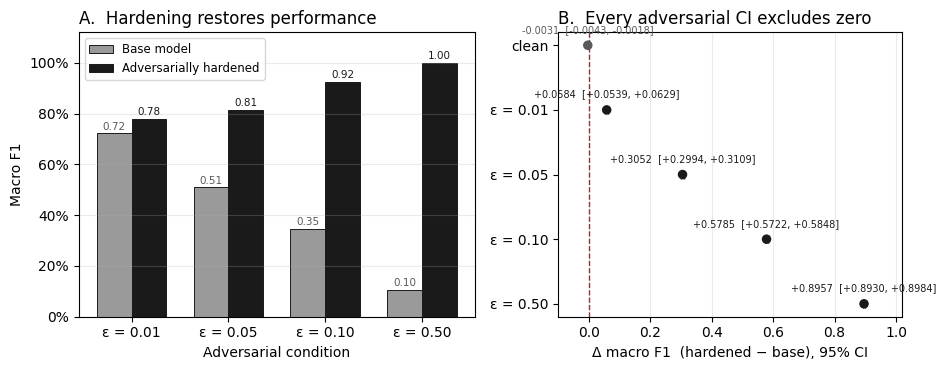

wrote Figure29_RQ4_adversarial_training.png and Figures/data/rq4_results.json


In [19]:
CONDS, base_f1v, hard_f1v, delta, dlo, dhi = [], [], [], [], [], []
for name, (Xe, ye) in _sig_eval.items():
    ye = np.asarray(ye)
    pb, ph = base_model.predict(Xe), _hard.predict(Xe)
    m = len(ye); idx = [rng.integers(0, m, m) for _ in range(N_BOOT)]
    d = np.array([f1_score(ye[i], ph[i], average="macro") - f1_score(ye[i], pb[i], average="macro") for i in idx])
    CONDS.append("clean" if "Control" in name else name.replace("Epsilon = ", "ε = "))
    base_f1v.append(f1_score(ye, pb, average="macro"))
    hard_f1v.append(f1_score(ye, ph, average="macro"))
    delta.append(float(d.mean()))
    lo, hi = np.percentile(d, [2.5, 97.5]); dlo.append(float(lo)); dhi.append(float(hi))
print("ΔF1 by condition:", [round(v, 4) for v in delta], "(expect ~ -0.003 / +0.059 / +0.305 / +0.578 / +0.896)")
INK, MID, LIGHT, RED = "#1a1a1a", "#5a5a5a", "#9a9a9a", "#b3242b"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})
adv = [i for i, c in enumerate(CONDS) if c != "clean"]
xb = np.arange(len(adv)); w = 0.36
ax1.bar(xb - w/2, [base_f1v[i] for i in adv], w, color=LIGHT, edgecolor=INK, lw=.7, label="Base model")
ax1.bar(xb + w/2, [hard_f1v[i] for i in adv], w, color=INK,   edgecolor=INK, lw=.7, label="Adversarially hardened")
for k, i in enumerate(adv):
    ax1.text(k - w/2, base_f1v[i] + .015, f"{base_f1v[i]:.2f}", ha="center", fontsize=7.5, color=MID)
    ax1.text(k + w/2, hard_f1v[i] + .015, f"{hard_f1v[i]:.2f}", ha="center", fontsize=7.5, color=INK)
ax1.set_xticks(xb); ax1.set_xticklabels([CONDS[i] for i in adv])
ax1.set_ylim(0, 1.12); ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax1.set_ylabel("Macro F1"); ax1.set_xlabel("Adversarial condition")
ax1.set_title("A.  Hardening restores performance", loc="left")
ax1.legend(loc="upper left", fontsize=8.5); ax1.grid(alpha=.25, axis="y")
y = np.arange(len(CONDS))[::-1]
for xi, yi, lo, hi in zip(delta, y, dlo, dhi):
    c = MID if xi < 0 else INK
    ax2.errorbar([xi], [yi], xerr=[[xi - lo], [hi - xi]], fmt="none", ecolor=c, elinewidth=1.4, capsize=3)
    ax2.annotate(f"{xi:+.4f}  [{lo:+.4f}, {hi:+.4f}]", xy=(xi, yi), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=7, color=c)
ax2.scatter(delta, y, s=34, c=[MID if v < 0 else INK for v in delta], zorder=3)
ax2.axvline(0, ls="--", lw=1.0, color=RED)
ax2.set_yticks(y); ax2.set_yticklabels(CONDS)
ax2.set_xlabel("Δ macro F1  (hardened − base), 95% CI")
ax2.set_title("B.  Every adversarial CI excludes zero", loc="left")
ax2.set_xlim(-0.10, 1.02); ax2.grid(alpha=.25, axis="x")
fig.tight_layout()
os.makedirs("Figures", exist_ok=True)
fig.savefig("Figures/Figure29_RQ4_adversarial_training.png", dpi=300, bbox_inches="tight")
plt.show()
os.makedirs("Figures/data", exist_ok=True)
json.dump({"conditions": CONDS, "base": base_f1v, "hardened": hard_f1v,
           "delta": delta, "delta_ci_low": dlo, "delta_ci_high": dhi},
          open("Figures/data/rq4_results.json", "w"), indent=2)
print("wrote Figure29_RQ4_adversarial_training.png and Figures/data/rq4_results.json")